<a href="https://colab.research.google.com/github/kayeneii/Floodgate/blob/main/floodgate_spatial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mapping Flood Risk Zones in Lagos Using Open Data (Cont'd)
## *Step 4: Spatial Analysis and River Proximity Mapping*
Perform river proximity masking and extract exposure features (roads, buildings, and settlements) using OSMnx

Key Libraries
- OSMnx → for extracting OSM features like rivers, roads, and buildings
- GeoPandas / Rasterio / rioxarray → for raster–vector integration
- Folium → for quick map visualization.

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
# Run once at the top of the notebook
!pip install overpy geopandas shapely rasterio rioxarray pyproj scipy folium -q

import overpy
import geopandas as gpd
from shapely.geometry import LineString, Point, mapping
import json, math, time
import rasterio
from rasterio import features
import numpy as np
from scipy.ndimage import distance_transform_edt
import rioxarray
import os

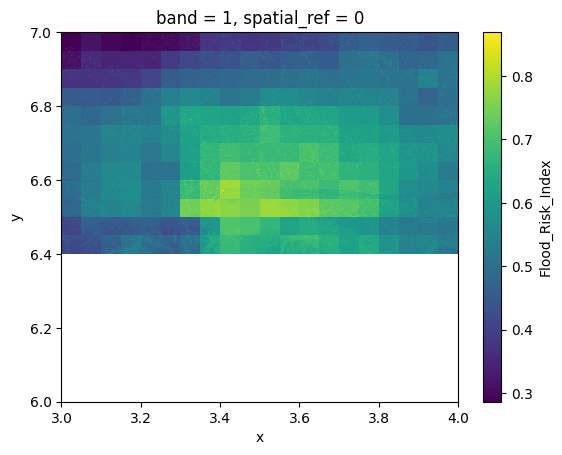

In [2]:
# Load processed data
fri_path = '/content/drive/MyDrive/floodgate_fri_geotiff.tif'

fri = rioxarray.open_rasterio(fri_path).squeeze()
fri.name = "Flood_Risk_Index"
fri.plot()

In [8]:
api = overpy.Overpass()

def fetch_waterways_overpass(minlon, minlat, maxlon, maxlat, timeout=180):
    """
    Fetch all ways and relations tagged waterway within bbox using Overpass via overpy.
    Returns overpy.Result object.
    """
    # Overpass bbox format: south,west,north,east
    south, west, north, east = minlat, minlon, maxlat, maxlon
    q = f"""
    [out:json][timeout:{timeout}];
    (
      way["waterway"]({south},{west},{north},{east});
      relation["waterway"]({south},{west},{north},{east});
    );
    out body;
    >;
    out skel qt;
    """
    return api.query(q)

In [10]:
def overpy_to_gdf(result):
    """
    Convert overpy.Result to GeoDataFrame of LineStrings (ways).
    Ignores relations for simplicity (most rivers are ways).
    """
    geoms = []
    props = []
    # Process ways
    for w in result.ways:
        # get node coordinates
        coords = [(float(n.lon), float(n.lat)) for n in w.nodes]
        if len(coords) < 2:
            continue
        geom = LineString(coords)
        # capture some tags (name, waterway)
        tags = dict(w.tags)
        props.append({
            'waterway': tags.get('waterway'),
            'name': tags.get('name'),
            **{k:v for k,v in tags.items() if k in ['waterway','name']}
        })
        geoms.append(geom)
    gdf = gpd.GeoDataFrame(props, geometry=geoms, crs='EPSG:4326')
    return gdf

In [12]:
# Run for your bbox
minlon, minlat, maxlon, maxlat = 3.0, 6.0, 4.0, 7.0
print('Querying Overpass. This may take 5-20 seconds...')
res = fetch_waterways_overpass(minlon, minlat, maxlon, maxlat)
rivers_gdf = overpy_to_gdf(res)
print('Extracted river features:', len(rivers_gdf))
rivers_gdf.head()

Querying Overpass. This may take 5-20 seconds...
Extracted river features: 1314


,waterway,name,geometry
0,stream,None,"LINESTRING (3.32662 6.51936, 3.32664 6.51802, ..."
1,ditch,None,"LINESTRING (3.34175 6.54444, 3.34036 6.54403, ..."
2,drain,None,"LINESTRING (3.4033 6.45489, 3.40389 6.4563, 3...."
3,stream,None,"LINESTRING (3.35688 6.51175, 3.35674 6.51159, ..."
4,ditch,None,"LINESTRING (3.34077 6.56672, 3.34078 6.56608, ..."


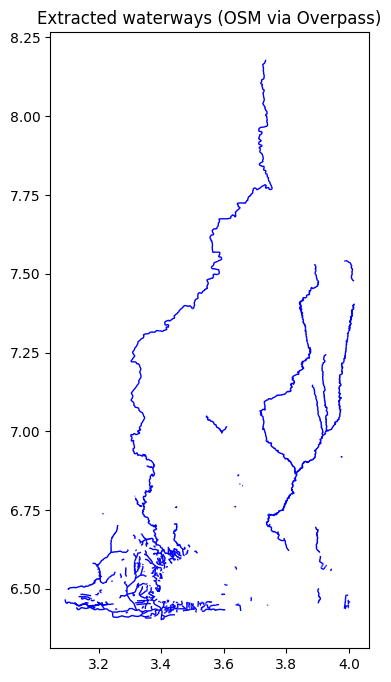

In [13]:
# quick plot (requires matplotlib)
import matplotlib.pyplot as plot
fig, ax = plot.subplots(figsize=(8,8))
rivers_gdf.plot(ax=ax, linewidth=1, color='blue')
ax.set_title('Extracted waterways (OSM via Overpass)')
plot.show()

In [15]:
# Save shapefile/GeoJSON to Drive folder
out_folder = '/content/drive/MyDrive/floodgate'
!mkdir -p "{out_folder}"
out_shp = out_folder + '/rivers_bbox_3_4_6_7.geojson'
rivers_gdf.to_file(out_shp, driver='GeoJSON')
print('Saved rivers to', out_shp)

Saved rivers to /content/drive/MyDrive/floodgate/rivers_bbox_3_4_6_7.geojson


Checking file: /content/drive/MyDrive/floodgate_fri_geotiff.tif
=== Raster info ===
Count (bands): 1
CRS: EPSG:4326
Transform: | 0.00, 0.00, 3.00|
| 0.00, 0.00, 6.00|
| 0.00, 0.00, 1.00|
Width, Height: 3712 3713
Bounds: BoundingBox(left=2.999889720934192, bottom=7.00052527264965, right=4.000253621329691, top=5.999891877668915)
Dtype: ('float32',)
Nodata: None
Valid pixel count: 1
Min / Max (valid): nan nan


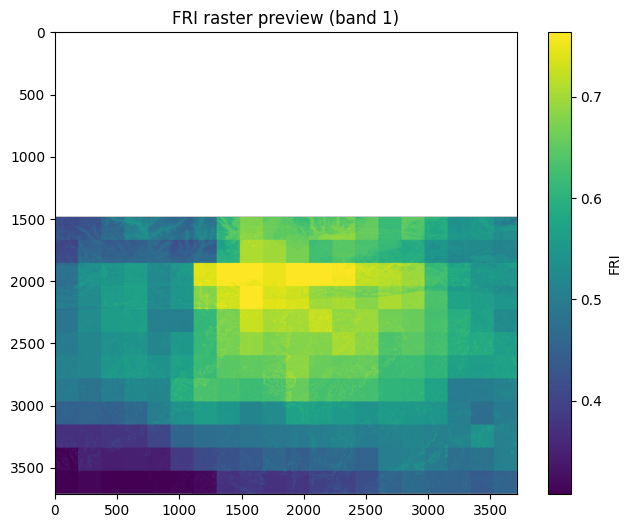

In [18]:
# Step 1: Verify FRI raster exists and inspect metadata
# Update this path if needed
fri_path = '/content/drive/MyDrive/floodgate_fri_geotiff.tif'

print("Checking file:", fri_path)
if not os.path.exists(fri_path):
    raise FileNotFoundError(f"FRI file not found at {fri_path}. Please confirm path.")

with rasterio.open(fri_path) as src:
    print("=== Raster info ===")
    print("Count (bands):", src.count)
    print("CRS:", src.crs)
    print("Transform:", src.transform)
    print("Width, Height:", src.width, src.height)
    print("Bounds:", src.bounds)
    print("Dtype:", src.dtypes)
    print("Nodata:", src.nodata)
    # Read first band
    arr = src.read(1, masked=True).astype('float32')
    print("Valid pixel count:", np.count_nonzero(~arr.mask))
    if np.count_nonzero(~arr.mask) > 0:
        print("Min / Max (valid):", float(arr.min()), float(arr.max()))
    else:
        print("Raster appears all nodata or masked.")

# Quick plot (clipped to non-nodata area for speed)
if np.count_nonzero(~arr.mask) > 0:
    # clip extreme values for visualization if large dynamic range
    vmin = np.nanpercentile(arr.compressed(), 2)
    vmax = np.nanpercentile(arr.compressed(), 98)
    plot.figure(figsize=(8,6))
    plot.imshow(arr, vmin=vmin, vmax=vmax)
    plot.title('FRI raster preview (band 1)')
    plot.colorbar(label='FRI')
    plot.show()
else:
    print("No valid pixels to plot.")

In [19]:
# Step 2: Repair FRI raster spatial metadata and save corrected version

import rasterio
from rasterio.transform import from_bounds
import numpy as np

fri_path = '/content/drive/MyDrive/floodgate_fri_geotiff.tif'
fri_fixed = '/content/drive/MyDrive/floodgate_fri_fixed.tif'

# Define correct bounding box for your study area
minx, miny, maxx, maxy = 3.0, 6.0, 4.0, 7.0

with rasterio.open(fri_path) as src:
    arr = src.read(1)
    height, width = arr.shape
    print("Original shape:", height, width)

# Build a transform that matches bbox and raster dimensions
transform = from_bounds(minx, miny, maxx, maxy, width, height)
crs = "EPSG:4326"

# Replace invalid or nan with nodata
arr = np.where(np.isfinite(arr), arr, np.nan)
nodata_val = -9999
arr_filled = np.nan_to_num(arr, nan=nodata_val)

# Save corrected raster
profile = {
    'driver': 'GTiff',
    'height': height,
    'width': width,
    'count': 1,
    'dtype': 'float32',
    'crs': crs,
    'transform': transform,
    'nodata': nodata_val
}

with rasterio.open(fri_fixed, 'w', **profile) as dst:
    dst.write(arr_filled.astype('float32'), 1)

print(f"✅ Fixed FRI saved to {fri_fixed}")

# Confirm new metadata
with rasterio.open(fri_fixed) as check:
    print("CRS:", check.crs)
    print("Transform:", check.transform)
    print("Bounds:", check.bounds)
    print("Width/Height:", check.width, check.height)

Original shape: 3713 3712
✅ Fixed FRI saved to /content/drive/MyDrive/floodgate_fri_fixed.tif
CRS: EPSG:4326
Transform: | 0.00, 0.00, 3.00|
| 0.00,-0.00, 7.00|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=3.0, bottom=6.0, right=4.0, top=7.0)
Width/Height: 3712 3713
